In [1]:
import siibra
from nilearn import plotting, image
import matplotlib.pyplot as plt
import numpy as np
import nibabel as nib
import plotly.graph_objects as go

import pyNN.neuron as sim
from pyNN import space
from pyNN.random import RandomDistribution, NumpyRNG
from pyNN.neuron import Projection, StaticSynapse, FixedNumberPreConnector
import pandas as pd
from scipy.interpolate import LinearNDInterpolator, NearestNDInterpolator

import scipy.signal as signal

[siibra:INFO] Version: 1.0.1-alpha.10
[siibra:WARNING] This is a development release. Use at your own risk.
[siibra:INFO] Please file bugs and issues at https://github.com/FZJ-INM1-BDA/siibra-python.
/home/tkmcg/neuron-env/lib/python3.12/site-packages/pyNN/neuron/__init__.py:14: UserWarning: mpi4py not available
  warnings.warn("mpi4py not available")


In [41]:
#class to get random points based on the STN in the Julich Brain CYTOARCHITECTURE
class Julich_brain_cyto_random_point_generator:
    def __init__(self,parcellation, region, space, stimulating_electrode_position, encapsulation_x, encapsulation_y):
        #obtain the brain region required
        self.region = siibra.get_region(parcellation, region)

        #get the space required
        self.space = self.region.spaces.get(space)


        self.region_map = self.region.get_regional_map(space, maptype="statistical")
        self.NIfTI_region = self.region_map.fetch()
        self.region_data = self.NIfTI_region.get_fdata()
        self.affine = self.NIfTI_region.affine
              

        ## Get voxel indices (i,j,k) of valid voxels
        self.region_data_indices = np.argwhere(self.region_data > 0)

        #stimulating electrode position and encapsulation
        self.stimulating_electrode_position = stimulating_electrode_position
        self.encapsulation_x = encapsulation_x
        self.encapsulation_y = encapsulation_y


    def generate_positions(self, number_points):
        indices = np.random.choice(len(self.region_data_indices), size = number_points)
        voxel_coords = self.region_data_indices[indices]        

        offsets = np.random.normal(0, 0.2, size=(number_points, 3))
        voxel_points = voxel_coords + offsets

        ones = np.ones((number_points, 1))
        vox_hom = np.hstack([voxel_points, ones])          
        world_points = (self.affine @ vox_hom.T).T[:, :3]

        #remove points from the encapsulation layer
        x_min, x_max, y_min, y_max = self.stimulating_electrode_position[0]-self.encapsulation_x, self.stimulating_electrode_position[0]+self.encapsulation_x, self.stimulating_electrode_position[1]-self.encapsulation_y, self.stimulating_electrode_position[1]+self.encapsulation_y

        mask = ~(
        (x_min < world_points[:, 0]) & (world_points[:, 0] < x_max) &
        (y_min < world_points[:, 1]) & (world_points[:, 1] < y_max))
        
        if mask.sum() < number_points:
            # recursively fill remaining points
            missing = number_points - mask.sum()
            extra = self.generate_positions(missing)
            world_points = np.vstack([world_points[mask], extra])
        else:
            world_points = world_points[mask][:number_points]
        
        return world_points


In [43]:
parcellation = "JULICH_BRAIN_CYTOARCHITECTONIC_ATLAS_V3_1" 
region = "STN (Subthalamus) right"
space = "MNI_152_ICBM_2009C_NONLINEAR_ASYMMETRIC"
stimulating_electrode_position = np.array([0,0,0])
encapsulation_x = 5
encapsulation_y = 5

random_point_generator = Julich_brain_cyto_random_point_generator(parcellation,region,space,stimulating_electrode_position,encapsulation_x,encapsulation_y)
random_point_generator.generate_positions(10)

array([[  5.27301449, -11.6752341 , -10.31334202],
       [ 10.07428409, -14.12015029,  -9.97378103],
       [  6.998183  , -13.73514759, -12.89799981],
       [ 12.89431653, -13.8143837 ,  -5.06821261],
       [  8.12582282, -15.85382689, -18.02965345],
       [ 12.0389232 , -20.07738334, -13.07568091],
       [  7.96327385, -10.22871755, -12.08121352],
       [ 17.221597  , -16.30546772,  -7.02565699],
       [  5.75128919, -14.94186442, -16.96371497],
       [  5.85809997, -14.028571  ,  -7.73403884]])

In [46]:
##### Add in the STN neurons and change the geometry to match the coupling project with DC current ####
v_init = -68
rng_seed = 856
n = 100
rotation_angle = 0.610865
parcellation = "JULICH_BRAIN_CYTOARCHITECTONIC_ATLAS_V3_1" 
region = "STN (Subthalamus) right"
space = "MNI_152_ICBM_2009C_NONLINEAR_ASYMMETRIC"
stimulating_electrode_position = np.array([10,-14,-12])
encapsulation_x = 5
encapsulation_y = 5

############ Setup the simulation##########
sim.setup(timestep=0.01)

###########set up the neuron type##############
cortical_type = sim.HH_cond_exp()
STN_type = sim.HH_cond_exp()

########## create a population of neurons ###############
cortical_pop = sim.Population(n, cortical_type, initial_values={'v': v_init}, label="Cortical neurons")
STN_pop = sim.Population(n, STN_type, initial_values={'v': v_init}, label="STN neurons")

######## positions of the cells #######################
random_point_generator = Julich_brain_cyto_random_point_generator(parcellation,region,space,stimulating_electrode_position,encapsulation_x,encapsulation_y)
STN_space = random_point_generator.generate_positions(n)

cortical_pop.positions[0], cortical_pop.positions[1],cortical_pop.positions[2] = STN_space[:,0], STN_space[:,1], STN_space[:,2]

####### Clean up ###########
sim.end()

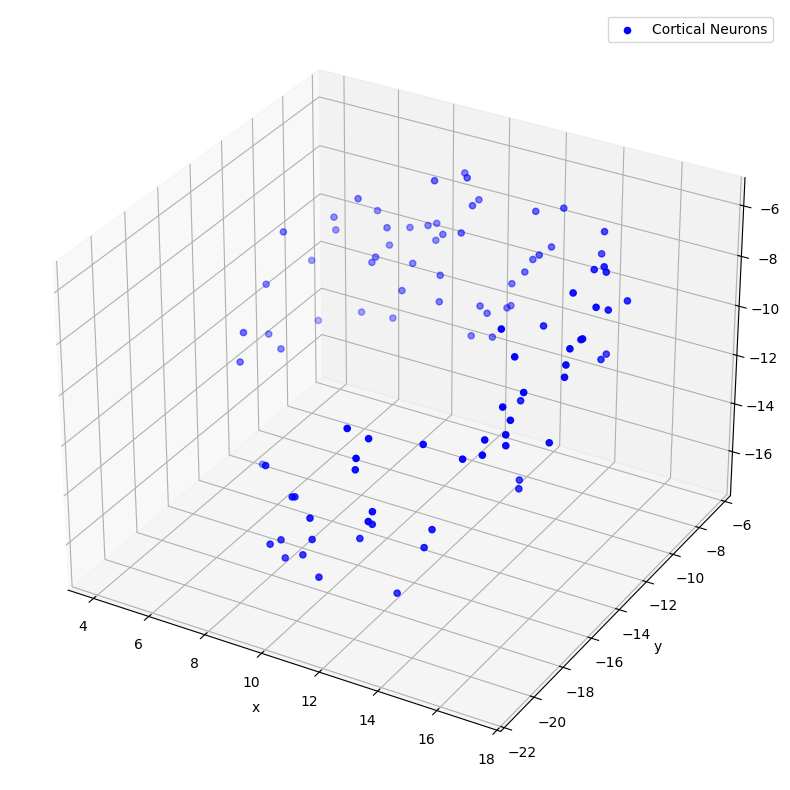

In [47]:
###### plot where the neurons are in the STn space #########
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
#%matplotlib widget

##############################################
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.set_xlabel('x')
ax.set_zlabel('z')
ax.set_ylabel('y')


##### add in the cortical neurons##############
x_points_clean_ctx = cortical_pop.positions[0]
y_points_clean_ctx = cortical_pop.positions[1]
z_points_clean_ctx = cortical_pop.positions[2]

ax.scatter(x_points_clean_ctx, y_points_clean_ctx, z_points_clean_ctx, c='blue', label = "Cortical Neurons")

ax.legend()

plt.show()